In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os

In [2]:
# Load dataset
df = pd.read_csv("data/RMBR4-2_export_test_linked.csv")

# 1. Filter for Robot 102
robot_102_df = df[df["Rob_Id"] == 102]

# 2. Extract Axis #4 series
axis4_records = robot_102_df["Axis #4"]
active_axis4 = axis4_records[axis4_records > 0]  # Filter for active records (greater than 0)

# 3. Calculate Mean and Median
mean_val = axis4_records.mean()
active_median = active_axis4.median()

print(f"Total Filtered Records: {len(axis4_records)}")
print(f"Axis #4 Mean: {mean_val:.4f}")
print(f"Active Median: {active_median:.5f}")

Total Filtered Records: 8023
Axis #4 Mean: 0.6122
Active Median: 0.95495


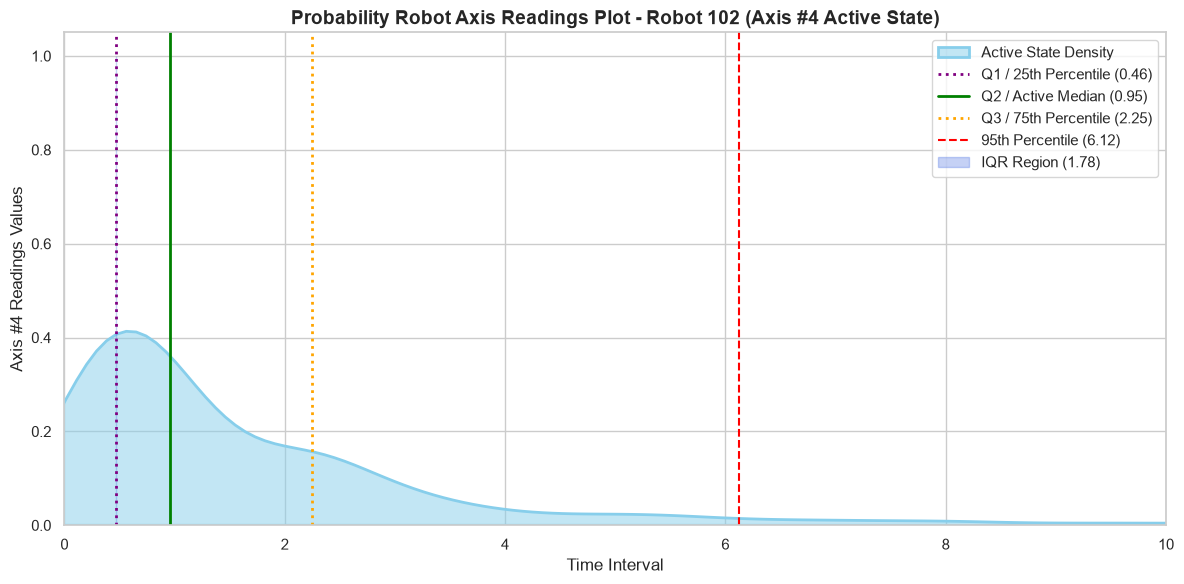

In [11]:
# 1. Load dataset
df = pd.read_csv("data/RMBR4-2_export_test_linked.csv")
df["Time"] = pd.to_datetime(df["Time"])

# 2. Filter active state for Robot 102 & Axis #4
df_rob102 = df[df["Rob_Id"] == 102]
axis4_active = df_rob102[df_rob102["Axis #4"] > 0]["Axis #4"]

# 3. Calculate Quantiles & Percentiles
q1 = axis4_active.quantile(0.25)
q2 = axis4_active.quantile(0.50)  # Active Median
q3 = axis4_active.quantile(0.75)
iqr = q3 - q1
p95 = axis4_active.quantile(0.95)

# 4. Generate Probability Density Plot
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Kernel Density Estimation curve
sns.kdeplot(
    axis4_active,
    fill=True,
    color="skyblue",
    alpha=0.5,
    linewidth=2,
    label="Active State Density",
)

# Overlay Quartile lines
plt.axvline(
    q1,
    color="purple",
    linestyle=":",
    linewidth=2,
    label=f"Q1 / 25th Percentile ({q1:.2f})",
)
plt.axvline(
    q2,
    color="green",
    linestyle="-",
    linewidth=2,
    label=f"Q2 / Active Median ({q2:.2f})",
)
plt.axvline(
    q3,
    color="orange",
    linestyle=":",
    linewidth=2,
    label=f"Q3 / 75th Percentile ({q3:.2f})",
)
plt.axvline(
    p95,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=f"95th Percentile ({p95:.2f})",
)

# Highlight Interquartile Range (IQR) under the curve
x_kde, y_kde = plt.gca().get_lines()[0].get_data()
plt.fill_between(
    x_kde,
    y_kde,
    where=(x_kde >= q1) & (x_kde <= q3),
    color="royalblue",
    alpha=0.3,
    label=f"IQR Region ({iqr:.2f})",
)

plt.title(
    "Probability Robot Axis Readings Plot - Robot 102 (Axis #4 Active State)",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Time Interval", fontsize=12)
plt.ylabel("Axis #4 Readings Values", fontsize=12)
plt.xlim(0, 10)
plt.legend(loc="upper right", frameon=True)
plt.tight_layout()
plt.show()